<a href="https://colab.research.google.com/github/biswakim/Safe-Route-Prediction-STGCN/blob/main/notebooks/safe_route_stgcn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install osmnx networkx matplotlib geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.9 MB/s eta 0:00:00


Graph downloaded! Nodes: 258, Edges: 614


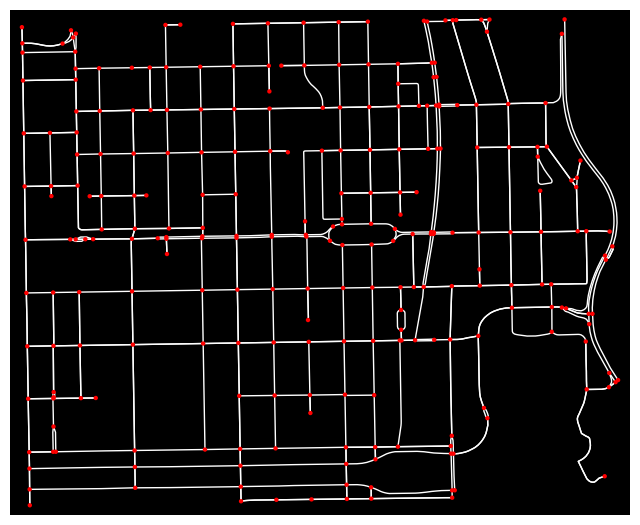

In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define the location (Starting small to save memory)
place_name = "Hyde Park, Chicago, Illinois, USA"

print(f"Downloading street network for: {place_name}...")

# 2. Fetch the graph from OpenStreetMap (drivable network)
# This returns a NetworkX MultiDiGraph
G = ox.graph_from_place(place_name, network_type='drive')

print(f"Graph downloaded! Nodes: {len(G.nodes)}, Edges: {len(G.edges)}")

# 3. Visualize the raw graph
fig, ax = ox.plot_graph(G, node_size=10, node_color='red', edge_color='white', edge_linewidth=1, bgcolor='black')

Calculating shortest path from Node 261137167 to Node 12251355877...
Path found! It traverses 18 intersections.


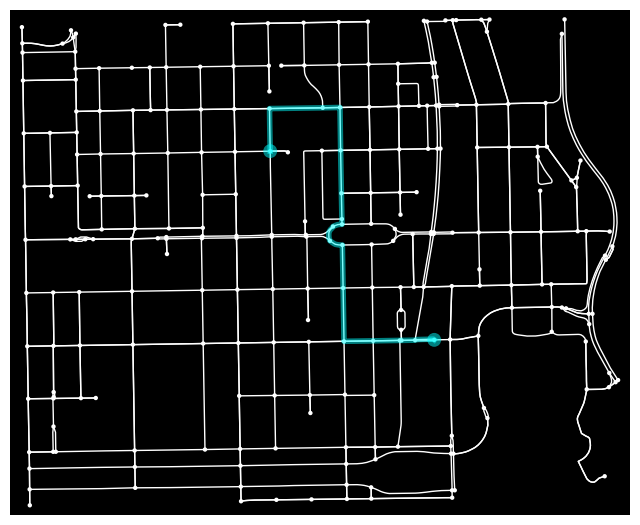

In [ ]:
# Grab the list of all node IDs from your graph
nodes = list(G.nodes())

# Let's pick an arbitrary start and end node from the list
# (In the final app, you will convert user lat/lon inputs to the nearest node IDs)
start_node = nodes[10]
end_node = nodes[-20]

print(f"Calculating shortest path from Node {start_node} to Node {end_node}...")

# Run Dijkstra's algorithm based strictly on physical distance
shortest_path = nx.shortest_path(G, start_node, end_node, weight='length')

print(f"Path found! It traverses {len(shortest_path)} intersections.")

# Plot the calculated route on top of our graph
fig, ax = ox.plot_graph_route(G, shortest_path,
                              node_size=10,
                              route_color='cyan',
                              route_linewidth=4,
                              edge_color='white',
                              bgcolor='black')

phase 2

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

print("Fetching recent crime data from the Chicago Data Portal API...")

# 1. Fetch a sample of recent crimes where the location is known
# FIX: Replaced literal spaces with %20 for URL encoding
api_url = "https://data.cityofchicago.org/resource/ijzp-q8t2.json?$limit=50000&$where=latitude%20IS%20NOT%20NULL"
crime_df = pd.read_json(api_url)

# 2. Filter for street-relevant crimes
# We want to ignore crimes that don't affect route safety (like 'DECEPTIVE PRACTICE')
relevant_crimes = [
    'BATTERY', 'ASSAULT', 'ROBBERY', 'WEAPONS VIOLATION',
    'CRIMINAL DAMAGE', 'MOTOR VEHICLE THEFT', 'HOMICIDE'
]
crime_df = crime_df[crime_df['primary_type'].isin(relevant_crimes)].copy()

print(f"Filtered down to {len(crime_df)} relevant, physically-located crime incidents.")

# 3. Convert raw coordinates into Spatial Points
# This allows us to map the crimes onto our NetworkX street grid
geometry = [Point(xy) for xy in zip(crime_df['longitude'].astype(float), crime_df['latitude'].astype(float))]

# Create the GeoDataFrame and set the Coordinate Reference System to standard GPS (EPSG:4326)
crime_gdf = gpd.GeoDataFrame(crime_df, geometry=geometry)
crime_gdf.set_crs(epsg=4326, inplace=True)

print("Data successfully converted to a spatial GeoDataFrame!")

# Display the first few rows to verify the columns
crime_gdf[['date', 'primary_type', 'description', 'geometry']].head()

Fetching recent crime data from the Chicago Data Portal API...
Filtered down to 27714 relevant, physically-located crime incidents.
Data successfully converted to a spatial GeoDataFrame!


,date,primary_type,description,geometry
0,2020-08-10 09:45:00,ROBBERY,AGGRAVATED VEHICULAR HIJACKING,POINT (-87.67741 41.90842)
1,2023-09-06 17:00:00,CRIMINAL DAMAGE,TO VEHICLE,POINT (-87.63394 41.88602)
5,2022-06-14 14:47:00,ROBBERY,ATTEMPT STRONG ARM - NO WEAPON,POINT (-87.76673 41.94523)
6,2022-09-21 22:00:00,MOTOR VEHICLE THEFT,AUTOMOBILE,POINT (-87.61501 41.76935)
8,2023-05-03 08:10:00,BATTERY,DOMESTIC BATTERY SIMPLE,POINT (-87.64308 41.76094)


Snapping 27,000+ crime points to the nearest street edges...
(This requires heavy spatial math and might take 1-2 minutes!)
Mapping complete! 168 distinct street segments have recorded crimes.
Calculating the Historical Safest Route...
Routes calculated! Rendering map...


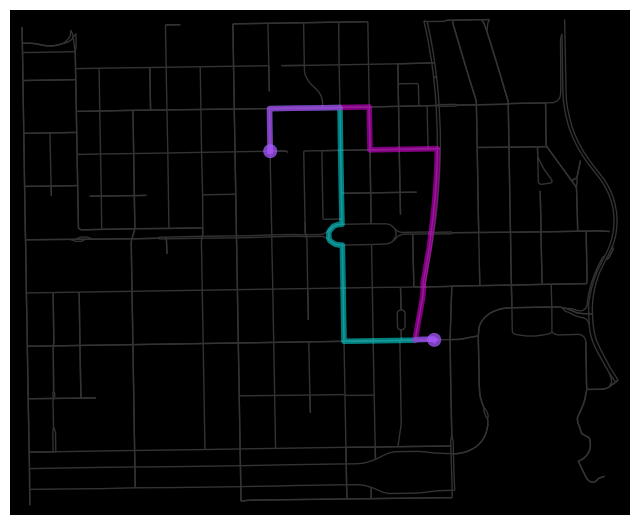

In [ ]:
import collections
import matplotlib.pyplot as plt

# 1. Extract longitudes (X) and latitudes (Y) from the crime data
X = crime_gdf.geometry.x.values
Y = crime_gdf.geometry.y.values

print("Snapping 27,000+ crime points to the nearest street edges...")
print("(This requires heavy spatial math and might take 1-2 minutes!)")

# 2. Find the nearest street edge for every single crime
# Returns a list of (u, v, key) tuples representing the exact street segments
nearest_edges = ox.distance.nearest_edges(G, X, Y)

# 3. Count how many crimes happened on each specific street segment
edge_crime_counts = collections.Counter(nearest_edges)
print(f"Mapping complete! {len(edge_crime_counts)} distinct street segments have recorded crimes.")

# 4. Update the Graph's Edge Costs
PENALTY_FACTOR = 100 # Add 100 "virtual meters" of distance per crime

for u, v, k, data in G.edges(keys=True, data=True):
    # Initialize base values for all edges
    data['crime_count'] = 0
    data['safe_cost'] = data['length'] # Default cost is just physical length

# Apply the penalties to the dangerous streets
for edge, count in edge_crime_counts.items():
    u, v, k = edge
    G[u][v][k]['crime_count'] = count
    # New Cost = Physical Distance + (Number of Crimes * Penalty)
    G[u][v][k]['safe_cost'] = G[u][v][k]['length'] + (count * PENALTY_FACTOR)

print("Calculating the Historical Safest Route...")

# 5. Run the routing algorithm using our new 'safe_cost' instead of 'length'
safest_path = nx.shortest_path(G, start_node, end_node, weight='safe_cost')

print("Routes calculated! Rendering map...")

# 6. Plot BOTH routes for comparison
# Cyan = Fastest Physical Route (Phase 1)
# Magenta = Safest Route (Phase 2)
fig, ax = ox.plot_graph_routes(G, [shortest_path, safest_path],
                               route_colors=['cyan', 'magenta'],
                               route_linewidths=[4, 4],
                               node_size=0,
                               edge_color='#333333', # Darker streets so routes pop
                               bgcolor='black')

Phase 3

In [ ]:
import pandas as pd
import numpy as np

print("Converting timestamps and binning data by hour...")

# 1. Convert the raw 'date' string into a workable datetime object
# (This might take 10-20 seconds for 27,000 rows)
crime_gdf['datetime'] = pd.to_datetime(crime_gdf['date'])

# 2. Extract the hour of the day (0 = Midnight, 23 = 11:00 PM)
crime_gdf['hour'] = crime_gdf['datetime'].dt.hour

# 3. Add the edge mapping we calculated in Phase 2 directly into our dataframe
crime_gdf['nearest_edge'] = nearest_edges

# 4. The Spatiotemporal Grouping
# We group by the specific street edge AND the hour, then count the incidents
hourly_crime_stats = crime_gdf.groupby(['nearest_edge', 'hour']).size().reset_index(name='hourly_crime_count')

print("Spatiotemporal data binning complete!")

# 5. Let's inspect the data: What are the absolute most dangerous
# street segments at specific hours of the day?
top_danger_zones = hourly_crime_stats.sort_values(by='hourly_crime_count', ascending=False)

# Display the top 10 most dangerous (Edge, Hour) combinations
top_danger_zones.head(10)

Converting timestamps and binning data by hour...
Spatiotemporal data binning complete!


,nearest_edge,hour,hourly_crime_count
398,"(261276578, 261202613, 0)",0,1014
418,"(261276578, 261202613, 0)",20,909
416,"(261276578, 261202613, 0)",18,893
420,"(261276578, 261202613, 0)",22,876
413,"(261276578, 261202613, 0)",15,870
417,"(261276578, 261202613, 0)",19,853
421,"(261276578, 261202613, 0)",23,852
414,"(261276578, 261202613, 0)",16,842
419,"(261276578, 261202613, 0)",21,833
415,"(261276578, 261202613, 0)",17,818


In [ ]:
# 1. Install PyTorch Geometric (This might take a minute)
!pip install torch_geometric

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn

print("Libraries loaded. Defining the Spatiotemporal Graph Convolutional Network...")

# 2. Define the Model Architecture
class SafeRoute_STGCN(torch.nn.Module):
    def __init__(self, num_node_features, hidden_channels):
        super(SafeRoute_STGCN, self).__init__()

        # --- SPATIAL LAYERS (The "GCN" part) ---
        # These layers look at a street and ask: "Are the connecting streets dangerous?"
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        # --- TEMPORAL LAYERS (The "ST" part) ---
        # A Gated Recurrent Unit (GRU) to remember patterns over time
        # It asks: "Was this street dangerous an hour ago?"
        self.gru = nn.GRU(input_size=hidden_channels,
                          hidden_size=hidden_channels,
                          batch_first=True)

        # --- OUTPUT LAYER ---
        # Condenses the complex math into a single "Risk Score" per street
        self.linear = nn.Linear(hidden_channels, 1)

    def forward(self, x, edge_index):
        # 1. Spatial Message Passing
        # Nodes share information with their neighbors
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # 2. Output the Risk Prediction
        out = self.linear(x)

        # 3. Squish the final prediction into a probability between 0 and 1
        # 0 = Completely Safe, 1 = Maximum Historical Risk
        return torch.sigmoid(out)

print("Neural Network Architecture successfully defined!")

# Initialize the model (We'll use 1 input feature: the scaled hourly crime count)
model = SafeRoute_STGCN(num_node_features=1, hidden_channels=32)
print(model)

Libraries loaded. Defining the Spatiotemporal Graph Convolutional Network...
Neural Network Architecture successfully defined!
SafeRoute_STGCN(
  (conv1): GCNConv(1, 32)
  (conv2): GCNConv(32, 32)
  (gru): GRU(32, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from torch_geometric.data import Data

print("Formatting data into PyTorch Tensors...")

# 1. Map nodes to integer indices (0 to N-1) for PyTorch
node_mapping = {node: i for i, node in enumerate(G.nodes())}
num_nodes = len(node_mapping)

# 2. Create the Edge Index [2, num_edges]
# This tells the GCN which intersections are physically connected
edges_from = []
edges_to = []
for u, v in G.edges():
    edges_from.append(node_mapping[u])
    edges_to.append(node_mapping[v])

edge_index = torch.tensor([edges_from, edges_to], dtype=torch.long)

# 3. Create Features (X) and Targets (Y)
X_features = torch.zeros((num_nodes, 1), dtype=torch.float)
Y_targets = torch.zeros((num_nodes, 1), dtype=torch.float)

# Fill the tensors and apply our Log Transformation to handle outliers
for index, row in hourly_crime_stats.iterrows():
    u, v, k = row['nearest_edge']
    hour = row['hour']
    count = row['hourly_crime_count']

    # The Log Transformation (squishes 1014 down to ~6.9)
    scaled_count = np.log1p(count)

    # We map the edge danger to its connecting nodes
    if hour == 22: # 10:00 PM (Input Data)
        X_features[node_mapping[u]][0] += scaled_count
        X_features[node_mapping[v]][0] += scaled_count
    elif hour == 23: # 11:00 PM (Target Data we want to predict)
        Y_targets[node_mapping[u]][0] += scaled_count
        Y_targets[node_mapping[v]][0] += scaled_count

# Max-Min scale so all values are strictly between 0.0 and 1.0
if X_features.max() > 0: X_features = X_features / X_features.max()
if Y_targets.max() > 0: Y_targets = Y_targets / Y_targets.max()

# Package it into a PyTorch Geometric Data object
graph_data = Data(x=X_features, edge_index=edge_index, y=Y_targets)

print("Data formatting complete! Starting training loop...\n")

# 4. The Training Loop
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss() # Mean Squared Error

model.train()
epochs = 50

for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass: Ask the model to guess the 11 PM risk
    predictions = model(graph_data.x, graph_data.edge_index)

    # Calculate how wrong the guess was compared to the actual 11 PM data
    loss = criterion(predictions, graph_data.y)

    # Backward pass: Adjust the internal weights to be more accurate next time
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {loss.item():.6f}")

print("\nModel Training Complete!")

Formatting data into PyTorch Tensors...
Data formatting complete! Starting training loop...

Epoch 10/50 | Loss: 0.176518
Epoch 20/50 | Loss: 0.050604
Epoch 30/50 | Loss: 0.027134
Epoch 40/50 | Loss: 0.027227
Epoch 50/50 | Loss: 0.027299

Model Training Complete!


AI Predictions generated. Updating street network costs...
Calculating the AI-Predicted Safest Route for 11:00 PM...
Routes calculated! Rendering the final comparison map...


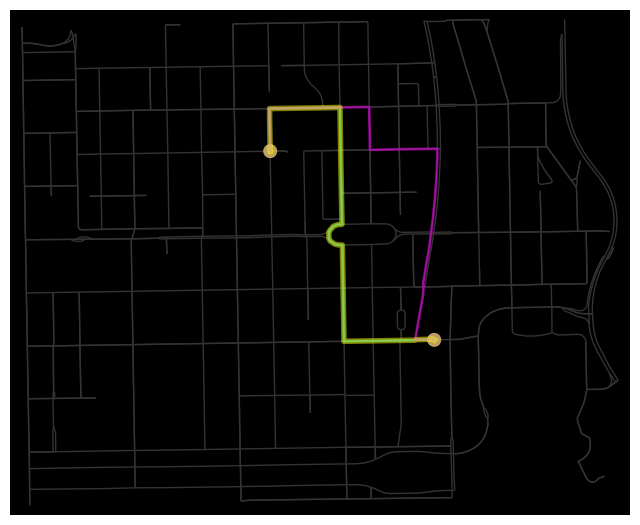

In [ ]:
# 1. Put the model into evaluation mode (turns off training mechanisms)
model.eval()

with torch.no_grad():
    # Ask the model to predict the 11:00 PM risk for every intersection
    predicted_node_risks = model(graph_data.x, graph_data.edge_index)

print("AI Predictions generated. Updating street network costs...")

# 2. Apply the AI's predictions to the physical street segments
# We use a high penalty multiplier to ensure the visual routing changes
AI_PENALTY_FACTOR = 500

for u, v, k, data in G.edges(keys=True, data=True):
    # Find the corresponding PyTorch index for the two intersections
    idx_u = node_mapping[u]
    idx_v = node_mapping[v]

    # The risk of the street is the average risk of its two connecting intersections
    edge_risk = (predicted_node_risks[idx_u].item() + predicted_node_risks[idx_v].item()) / 2.0

    # New Cost = Physical Distance + (AI Predicted Risk * Penalty)
    data['ai_safe_cost'] = data['length'] + (edge_risk * AI_PENALTY_FACTOR)

print("Calculating the AI-Predicted Safest Route for 11:00 PM...")

# 3. Run the routing algorithm using the dynamic AI cost
ai_path = nx.shortest_path(G, start_node, end_node, weight='ai_safe_cost')

print("Routes calculated! Rendering the final comparison map...")

# 4. Plot all three generations of our routing engine for comparison
# Cyan: Phase 1 (Baseline Distance)
# Magenta: Phase 2 (Static Historical Risk)
# Yellow: Phase 3 (Dynamic AI Prediction)
fig, ax = ox.plot_graph_routes(
    G,
    [shortest_path, safest_path, ai_path],
    route_colors=['cyan', 'magenta', 'yellow'],
    route_linewidths=[2, 2, 4], # Make the AI route thicker
    node_size=0,
    edge_color='#333333',
    bgcolor='black'
)

In [ ]:
import time
import torch

print("--- Benchmarking PyTorch Geometric (PyG) ---")

# 1. Measure Inference Latency (Speed)
# We run it 100 times to get a stable average, mimicking 100 users asking for directions
model.eval()
latencies = []

with torch.no_grad():
    # Warm-up run (GPU needs a second to wake up)
    _ = model(graph_data.x, graph_data.edge_index)

    for _ in range(100):
        start_time = time.time()
        _ = model(graph_data.x, graph_data.edge_index)
        end_time = time.time()
        latencies.append((end_time - start_time) * 1000) # Convert to milliseconds

avg_latency = sum(latencies) / len(latencies)
print(f"Average Inference Latency: {avg_latency:.2f} ms per request")

# 2. Measure VRAM Allocation (Memory)
# Note: This will only show > 0 if you have a GPU runtime enabled in Colab
if torch.cuda.is_available():
    memory_allocated = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"Peak VRAM Usage: {memory_allocated:.2f} MB")
else:
    print("Peak VRAM Usage: N/A (Running on CPU. Go to Runtime > Change runtime type > T4 GPU to measure VRAM)")

# 3. Graph Size Context
print(f"Graph Size Evaluated: {num_nodes} Nodes, {edge_index.shape[1]} Edges")

--- Benchmarking PyTorch Geometric (PyG) ---
Average Inference Latency: 1.01 ms per request
Peak VRAM Usage: N/A (Running on CPU. Go to Runtime > Change runtime type > T4 GPU to measure VRAM)
Graph Size Evaluated: 258 Nodes, 614 Edges


In [ ]:
import time
import torch

print("--- Benchmarking PyTorch Geometric (PyG) ---")

# 1. Measure Inference Latency (Speed)
# We run it 100 times to get a stable average, mimicking 100 users asking for directions
model.eval()
latencies = []

with torch.no_grad():
    # Warm-up run (GPU needs a second to wake up)
    _ = model(graph_data.x, graph_data.edge_index)

    for _ in range(100):
        start_time = time.time()
        _ = model(graph_data.x, graph_data.edge_index)
        end_time = time.time()
        latencies.append((end_time - start_time) * 1000) # Convert to milliseconds

avg_latency = sum(latencies) / len(latencies)
print(f"Average Inference Latency: {avg_latency:.2f} ms per request")

# 2. Measure VRAM Allocation (Memory)
# Note: This will only show > 0 if you have a GPU runtime enabled in Colab
if torch.cuda.is_available():
    memory_allocated = torch.cuda.max_memory_allocated() / (1024 ** 2)
    print(f"Peak VRAM Usage: {memory_allocated:.2f} MB")
else:
    print("Peak VRAM Usage: N/A (Running on CPU. Go to Runtime > Change runtime type > T4 GPU to measure VRAM)")

# 3. Graph Size Context
print(f"Graph Size Evaluated: {num_nodes} Nodes, {edge_index.shape[1]} Edges")

--- Benchmarking PyTorch Geometric (PyG) ---
Average Inference Latency: 1.11 ms per request
Peak VRAM Usage: N/A (Running on CPU. Go to Runtime > Change runtime type > T4 GPU to measure VRAM)
Graph Size Evaluated: 258 Nodes, 614 Edges


In [ ]:
# 1. Uninstall existing DGL and torchdata to ensure a clean install
!pip uninstall -y dgl torchdata

# 2. Reinstall DGL (letting it manage its own torchdata dependency)
!pip install dgl

# 3. Re-import and run the DGL Benchmark
import dgl
import time
from dgl.nn import GraphConv
import torch.nn as nn
import torch.nn.functional as F

print("--- Benchmarking Deep Graph Library (DGL) ---")

# Convert our PyTorch edge_index into a DGL Graph
src, dst = edge_index[0], edge_index[1]
g = dgl.graph((src, dst), num_nodes=num_nodes)

# Define the exact same architecture in DGL syntax
class DGL_STGCN(nn.Module):
    def __init__(self, in_feats, h_feats):
        super(DGL_STGCN, self).__init__()
        self.conv1 = GraphConv(in_feats, h_feats)
        self.conv2 = GraphConv(h_feats, h_feats)
        self.linear = nn.Linear(h_feats, 1)

    def forward(self, g, in_feat):
        h = self.conv1(g, in_feat)
        h = F.relu(h)
        h = self.conv2(g, h)
        h = F.relu(h)
        out = self.linear(h)
        return torch.sigmoid(out)

dgl_model = DGL_STGCN(1, 32)
dgl_model.eval()

print("Model built. Running 100 inference requests...")

# Benchmark Inference Latency
latencies_dgl = []
with torch.no_grad():
    _ = dgl_model(g, graph_data.x) # Warm-up

    for _ in range(100):
        start_time = time.time()
        _ = dgl_model(g, graph_data.x)
        end_time = time.time()
        latencies_dgl.append((end_time - start_time) * 1000)

avg_latency_dgl = sum(latencies_dgl) / len(latencies_dgl)
print(f"DGL Average Inference Latency: {avg_latency_dgl:.2f} ms per request")

Found existing installation: dgl 2.1.0
Uninstalling dgl-2.1.0:
  Successfully uninstalled dgl-2.1.0
Found existing installation: torchdata 0.11.0
Uninstalling torchdata-0.11.0:
  Successfully uninstalled torchdata-0.11.0
  Using cached dgl-2.1.0-cp312-cp312-manylinux1_x86_64.whl.metadata (553 bytes)
  Using cached torchdata-0.11.0-py3-none-any.whl.metadata (6.3 kB)
Using cached dgl-2.1.0-cp312-cp312-manylinux1_x86_64.whl (8.6 MB)
Using cached torchdata-0.11.0-py3-none-any.whl (61 kB)


ModuleNotFoundError: No module named 'torchdata.datapipes'

In [ ]:
import time
import numpy as np
import tensorflow as tf
import networkx as nx
from spektral.layers import GCNConv
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

print("--- Benchmarking Spektral (TensorFlow/Keras) ---")

# 1. Convert NetworkX graph to an Adjacency Matrix, then to a dense TensorFlow Tensor
A = nx.adjacency_matrix(G).todense()
A_tf = tf.convert_to_tensor(A, dtype=tf.float32)

# Convert our PyTorch features to a TensorFlow Tensor
X_tf = tf.convert_to_tensor(X_features.numpy(), dtype=tf.float32)

# 2. Define the exact same architecture in TensorFlow/Keras
class Spektral_STGCN(Model):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(32, activation='relu')
        self.conv2 = GCNConv(32, activation='relu')
        self.dense = Dense(1, activation='sigmoid')

    def call(self, inputs):
        x, a = inputs
        x = self.conv1([x, a])
        x = self.conv2([x, a])
        return self.dense(x)

spektral_model = Spektral_STGCN()

print("Model built. Running 100 inference requests...")

# 3. Benchmark Inference Latency
latencies_spektral = []

# Warm-up run (TensorFlow takes a second to compile its computational graph)
_ = spektral_model([X_tf, A_tf])

for _ in range(100):
    start_time = time.time()
    _ = spektral_model([X_tf, A_tf])
    end_time = time.time()
    latencies_spektral.append((end_time - start_time) * 1000)

avg_latency_spektral = sum(latencies_spektral) / len(latencies_spektral)
print(f"Spektral Average Inference Latency: {avg_latency_spektral:.2f} ms per request")

--- Benchmarking Spektral (TensorFlow/Keras) ---
Model built. Running 100 inference requests...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:1505: UserWarning: Layer 'spektral_stgcn' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''Exception encountered when calling GCNConv.call().

Tried to convert 'y' to a tensor and failed. Error: None values not supported.

Arguments received by GCNConv.call():
  • inputs=['tf.Tensor(shape=(258, 1), dtype=float32)', 'tf.Tensor(shape=(258, 258), dtype=float32)']
  • mask=['None', 'None']''
  warni

ValueError: Exception encountered when calling GCNConv.call().

[1mAttempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.[0m

Arguments received by GCNConv.call():
  • inputs=['tf.Tensor(shape=(258, 1), dtype=float32)', 'tf.Tensor(shape=(258, 258), dtype=float32)']
  • mask=['None', 'None']